# Import libraries

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
import os

# Add project root to path to allow imports from TBMD
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

# Local TBMD module imports
from TBMD.core.decomposition.hosvd import TuckerDecomposer
from TBMD.core.sensor_placement.tensor_qr_factorization import (
    TensorTubeQRDecomposition,
)
from TBMD.core.reconstruction.tensor_compressive_sensing import (
    TensorCompressiveSensing,
    CompressiveSensingConfig
)

from TBMD.data_utils.loaders import DataLoader
from TBMD.data_utils.splitters import split_data_in_memory_ordered
from TBMD.data_utils.processors import (
    process_data, 
    calculate_global_minmax_params, 
    calculate_global_zscore_params
)

from TBMD.core.decomposition.geometry_aware import GeometryAwareTuckerDecomposer, GeometryAwareConfig
from TBMD.core.sensor_placement.geometry_aware import GeometryAwareTensorQR, GeometricQRConfig
from TBMD.core.reconstruction.geometry_aware import (
    GeometryAwareTensorCS,
    GeometryAwareCSConfig,
)

from TBMD.utils.tbmd_utils import reconstruct_tensor
from TBMD.data_utils.processors import inverse_normalization
from TBMD.visualization.plots import plot_two_matrices, plot_original_reconstructed_diff
from TBMD.utils.metrics import compute_metrics

from TBMD.core.geometry import MeshGraphBuilder, MeshGeometry
from TBMD.utils.tbmd_utils import get_torch_device

from TBMD.config.base_config import BaseConfig

In [2]:
config = BaseConfig()
config._set_seed()
config.to_dict()

{'backend': 'pytorch',
 'dtype': 'float32',
 'device': 'cpu',
 'seed': 0,
 'deterministic': True,
 'verbose': True,
 'log_level': 'INFO'}

# Download data

In [3]:
loader = DataLoader()

### Load Brugge data

In [4]:
# Define paths relative to the project root
import os
from pathlib import Path

# Assuming the notebook is in algorithm/ and data is in data/
project_root = Path("..").resolve()
data_dir = project_root / "data" / "Brugge data"

tensors_path = data_dir / "data_exp_4_.h5"
wells_path = data_dir / "all_wells_exp_4.json"

print(f"Loading tensors from: {tensors_path}")
tensors = DataLoader.load_h5_tensors(str(tensors_path))
wells = DataLoader.load_wells_from_json(str(wells_path))

Loading tensors from: /Users/denissamatov/Heriot-Watt/Tensors/tensor-based-modal-decomposition-method/data/Brugge data/data_exp_4_.h5


In [5]:
for case_id in wells:
    # wells[case_id] is a list of [x,y] coordinate pairs.
    # This list comprehension iterates through each pair [x,y]
    # and creates a new pair [y,x], effectively swapping them.
    # The new list of swapped pairs replaces the original list for that case_id.
    wells[case_id] = [[y, x] for x, y in wells[case_id]]

# Display the modified wells dictionary
wells

{'case1': [[27, 54],
  [28, 81],
  [34, 46],
  [36, 64],
  [32, 82],
  [41, 75],
  [31, 104],
  [44, 95],
  [39, 103],
  [26, 62],
  [45, 52],
  [32, 90],
  [37, 71],
  [43, 81],
  [43, 31],
  [28, 71],
  [45, 69],
  [38, 37],
  [45, 42],
  [45, 61],
  [36, 96],
  [27, 91],
  [44, 100],
  [33, 74],
  [34, 98],
  [41, 66],
  [37, 55],
  [42, 111],
  [42, 51],
  [41, 44]],
 'case10': [[27, 54],
  [28, 81],
  [34, 46],
  [36, 64],
  [32, 82],
  [41, 75],
  [31, 104],
  [44, 95],
  [39, 103],
  [26, 62],
  [45, 52],
  [32, 90],
  [37, 71],
  [43, 81],
  [43, 31],
  [28, 71],
  [45, 69],
  [38, 37],
  [45, 42],
  [45, 61],
  [36, 96],
  [27, 91],
  [44, 100],
  [33, 74],
  [34, 98],
  [41, 66],
  [37, 55],
  [42, 111],
  [42, 51],
  [41, 44]],
 'case2': [[27, 54],
  [28, 81],
  [34, 46],
  [36, 64],
  [32, 82],
  [41, 75],
  [31, 104],
  [44, 95],
  [39, 103],
  [26, 62],
  [45, 52],
  [32, 90],
  [37, 71],
  [43, 81],
  [43, 31],
  [28, 71],
  [45, 69],
  [38, 37],
  [45, 42],
  [45, 61],


In [6]:
# train_data, test_data = split_data_in_memory_ordered(tensors['all'], train_ratio=0.8)

# subject_name = list(tensors['all'].keys())[0]

# print(list(tensors['all'].keys()))
# print(tensors['all'][subject_name].shape)

In [7]:
train_data, test_data = split_data_in_memory_ordered(tensors['pressure'], train_ratio=0.8)

subject_name = list(tensors['pressure'].keys())[2]

print(list(tensors['pressure'].keys()))
print(tensors['pressure'][subject_name].shape)

Experiments processed: 100%|██████████| 10/10 [00:00<00:00, 100824.62it/s]

['case1', 'case2', 'case3', 'case4', 'case5', 'case6', 'case7', 'case8', 'case9', 'case10']
(139, 48, 133)


In [8]:
# train_data, test_data = split_data_in_memory_ordered(tensors['soil'], train_ratio=0.8)

# subject_name = list(tensors['soil'].keys())[0]

# print(list(tensors['soil'].keys()))
# print(tensors['soil'][subject_name].shape)

# Process data

In [9]:
# Decide what counts as background (CT example)
BG = None        # Hounsfield Units for air

# 1.  Build masks once if you have them, otherwise just pass background_value
train_global_min, train_global_max = calculate_global_minmax_params(train_data,
                                                                    background_value=BG)
train_global_mean, train_global_std = calculate_global_zscore_params(train_data,
                                                                     background_value=BG)

# 2.  Pack the globals
minmax_params = {'min': train_global_min, 'max': train_global_max}
zscore_params = {'mean': train_global_mean, 'std': train_global_std}

print(minmax_params)
print(zscore_params)

{'min': 0.0, 'max': 171.8720422674243}
{'mean': 118.54628028736462, 'std': 70.1100889541879}


In [10]:
resize_shape = None
convert_to_grayscale = False
normalization_method = "minmax"  # "zscore" or "minmax"

print("Processing train data:")
train_tensors = process_data(
    train_data,
    resize_shape=resize_shape,
    convert_to_grayscale=convert_to_grayscale,
    normalization_method=normalization_method,
    global_params=minmax_params,                
    background_value=BG
)

print("\nProcessing test data:")
test_tensors = process_data(
    test_data,
    resize_shape=resize_shape,
    convert_to_grayscale=convert_to_grayscale,
    normalization_method=normalization_method,
    global_params=minmax_params,
    background_value=BG
)

num_images_train = {subject: tensor.shape[-1] for subject, tensor in train_tensors.items()}
num_images_test  = {subject: tensor.shape[-1] for subject, tensor in test_tensors.items()}

if num_images_train:
    min_train_images = min(num_images_train.values())
    print(f"\nMinimum number of images in train: {min_train_images}")
else:
    print("\nNo data available for analysis in train.")

if num_images_test:
    min_test_images = min(num_images_test.values())
    print(f"Minimum number of images in test: {min_test_images}")
else:
    print("No data available for analysis in test.")

Processing train data:

DATA PROCESSING CONFIGURATION
▸ Resize shape:          No resizing
▸ Convert to grayscale:  False
▸ Normalization method:  minmax
  ↳ Global min/max:      0.0000 / 171.8720
▸ Background value:      None



Processing subjects: 100%|██████████| 10/10 [00:00<00:00, 269.28it/s]


case1: (139, 48, 106)
case2: (139, 48, 106)
case3: (139, 48, 106)
case4: (139, 48, 106)
case5: (139, 48, 106)
case6: (139, 48, 106)
case7: (139, 48, 106)
case8: (139, 48, 106)
case9: (139, 48, 106)
case10: (139, 48, 106)

Processing test data:

DATA PROCESSING CONFIGURATION
▸ Resize shape:          No resizing
▸ Convert to grayscale:  False
▸ Normalization method:  minmax
  ↳ Global min/max:      0.0000 / 171.8720
▸ Background value:      None



Processing subjects: 100%|██████████| 10/10 [00:00<00:00, 1268.39it/s]

case1: (139, 48, 27)
case2: (139, 48, 27)
case3: (139, 48, 27)
case4: (139, 48, 27)
case5: (139, 48, 27)
case6: (139, 48, 27)
case7: (139, 48, 27)
case8: (139, 48, 27)
case9: (139, 48, 27)
case10: (139, 48, 27)

Minimum number of images in train: 106
Minimum number of images in test: 27


# Geometry Aware TBMD

## Data preparation

In [11]:
# ============================================================
# ПОДГОТОВКА ДАННЫХ ДЛЯ GEOMETRY-AWARE TBMD
# ============================================================

print(f"{'='*70}")
print(f"Подготовка данных для Geometry-Aware TBMD".center(70))
print(f"{'='*70}")

# Использовать весь батч tensors
tensor = train_tensors

# Получить параметры из первого case
first_case = list(tensor.keys())[0]
sample_data = tensor[first_case]

# -------------------------------------------------------------------------
# ВАЖНО: Интерпретация размерностей
# Тензор имеет форму (Dim1, Dim2, [Dim3], Time)
# Последняя координата ВСЕГДА считается временной (Time).
# Все предыдущие координаты считаются пространственными (Spatial).
#
# Пример 2D+Time: (Nx, Ny, T) -> Пространство (Nx, Ny), Время T
# Пример 3D+Time: (Nx, Ny, Nz, T) -> Пространство (Nx, Ny, Nz), Время T
# -------------------------------------------------------------------------

spatial_shape = sample_data.shape[:-1]
spatial_cells = np.prod(spatial_shape)
time_steps = sample_data.shape[-1]

print(f"✓ Данные загружены:")
print(f"  Количество cases: {len(tensor)}")
print(f"  Форма тензора: {sample_data.shape}")
print(f"  Интерпретация:")
print(f"    Пространственные оси: {spatial_shape} (Всего ячеек: {spatial_cells})")
print(f"    Временная ось: {time_steps} шагов (Последняя размерность)")

# Параметры эксперимента
# Ранги Такера: [R_space_1, R_space_2, ..., R_time]
if len(spatial_shape) == 2:
    # Для (Nx, Ny, T) -> [Rx, Ry, Rt]
    tucker_rank = [48, 48, 48] 
    print(f"  Конфигурация: 2D Пространство + Время")
elif len(spatial_shape) == 3:
    # Для (Nx, Ny, Nz, T) -> [Rx, Ry, Rz, Rt]
    tucker_rank = [20, 20, 5, 48]
    print(f"  Конфигурация: 3D Пространство + Время")

n_sensors = 25
sampling_rate = n_sensors / spatial_cells * 100

print(f"✓ Параметры эксперимента:")
print(f"  Tucker rank: {tucker_rank}")
print(f"  Количество сенсоров: {n_sensors}")
print(f"  Sampling rate: {sampling_rate:.2f}%")

              Подготовка данных для Geometry-Aware TBMD               
✓ Данные загружены:
  Количество cases: 10
  Форма тензора: (139, 48, 106)
  Интерпретация:
    Пространственные оси: (139, 48) (Всего ячеек: 6672)
    Временная ось: 106 шагов (Последняя размерность)
  Конфигурация: 2D Пространство + Время
✓ Параметры эксперимента:
  Tucker rank: [48, 48, 48]
  Количество сенсоров: 25
  Sampling rate: 0.37%


## MESH geometry

In [12]:
# ============================================================
# 1. ПОСТРОЕНИЕ ГРАФА СЕТКИ (MESH GEOMETRY)
# ============================================================

print(f"{'='*70}")
print(f"1. Построение графа сетки".center(70))
print(f"{'='*70}")

# Строим граф связности для регулярной сетки (Grid)
# Это критически важно для Geometry-Aware методов
builder = MeshGraphBuilder(connectivity_type='grid')
mesh = builder.build_from_shape(spatial_shape)

print(f"✓ Граф построен:")
print(f"  Узлов: {mesh.n_nodes}")
print(f"  Рёбер: {mesh.adjacency_matrix.nnz // 2}")
print(f"  Laplacian matrix: {mesh.laplacian_matrix.shape}")

                      1. Построение графа сетки                       
✓ Граф построен:
  Узлов: 6672
  Рёбер: 13157
  Laplacian matrix: (6672, 6672)
✓ Граф построен:
  Узлов: 6672
  Рёбер: 13157
  Laplacian matrix: (6672, 6672)


## Geometry-Aware HOSVD

In [13]:
# ============================================================
# 2. GEOMETRY-AWARE HOSVD (DECOMPOSITION)
# ============================================================

print(f"{'='*70}")
print(f"2. Geometry-Aware HOSVD".center(70))
print(f"{'='*70}")

device = get_torch_device()
print(f"Device: {device}")

# Конфигурация с Laplacian регуляризацией
hosvd_config = GeometryAwareConfig(
    alpha=0.05,              # Сила сглаживания (Tikhonov parameter)
    spatial_modes=[0],       # Регуляризуем пространственную моду
    laplacian_type='normalized'
)

# Определяем ранги для сплющенного тензора (Space, Time)
ranks = [min(spatial_cells, 50), min(time_steps, 50)]

# Храним результаты декомпозиции для всех cases
all_cores = {}
all_factors = {}

print(f"Запуск Geometry-Aware HOSVD для {len(tensor)} cases...")

for case_name, tensor_data in tensor.items():
    print(f"  Обработка {case_name}... форма: {tensor_data.shape}")
    
    decomposer = GeometryAwareTuckerDecomposer(
        tensor=tensor_data,      # Передаем исходный тензор (Nx, Ny, [Nz], T)
        mesh=mesh,               # MeshGeometry (автоматически обработается)
        geo_config=hosvd_config,
        ranks=ranks,
        device=str(device)
    )
    
    decomposer.decompose()
    
    # Сохраняем результаты
    all_cores[case_name] = decomposer.cores
    all_factors[case_name] = decomposer.factors

print(f"✓ Декомпозиция завершена для {len(all_cores)} cases")
print(f"  Core shape: {list(all_cores.values())[0].shape}")
print(f"  Spatial factor shape: {list(all_factors.values())[0][0].shape}")
print(f"  Temporal factor shape: {list(all_factors.values())[0][1].shape}")

                       2. Geometry-Aware HOSVD                        
Device: cpu
Запуск Geometry-Aware HOSVD для 10 cases...
  Обработка case1... форма: (139, 48, 106)
  Обработка case2... форма: (139, 48, 106)
  Обработка case2... форма: (139, 48, 106)
  Обработка case3... форма: (139, 48, 106)
  Обработка case3... форма: (139, 48, 106)
  Обработка case4... форма: (139, 48, 106)
  Обработка case4... форма: (139, 48, 106)
  Обработка case5... форма: (139, 48, 106)
  Обработка case5... форма: (139, 48, 106)
  Обработка case6... форма: (139, 48, 106)
  Обработка case6... форма: (139, 48, 106)
  Обработка case7... форма: (139, 48, 106)
  Обработка case7... форма: (139, 48, 106)
  Обработка case8... форма: (139, 48, 106)
  Обработка case8... форма: (139, 48, 106)
  Обработка case9... форма: (139, 48, 106)
  Обработка case9... форма: (139, 48, 106)
  Обработка case10... форма: (139, 48, 106)
  Обработка case10... форма: (139, 48, 106)
✓ Декомпозиция завершена для 10 cases
  Core shape: to

## Stack Spatial Basis from All Cases

In [18]:
# ============================================================
# 2.1 СОЗДАНИЕ ПРОСТРАНСТВЕННОГО БАЗИСА (Time-Insensitive Modes)
# ============================================================
# 
# КРИТИЧЕСКОЕ ИСПРАВЛЕНИЕ:
# 
# В классическом TBMD time-insensitive modes вычисляются как:
#   M_n = U_x @ G[:,:,n] @ U_y.T
# 
# Это включает информацию из CORE TENSOR, который содержит
# корреляции между пространством и временем.
#
# Для Geometry-Aware HOSVD с 2D core (R_spatial, R_time):
#   Modal tensor = U_spatial @ Core
# 
# Это математически эквивалентно time-insensitive modes,
# но упрощено для случая сплющенного пространства.
#
# НЕПРАВИЛЬНО (было): A = cat([U_spatial_1, U_spatial_2, ...])
# ПРАВИЛЬНО (сейчас): A = cat([U_spatial_1 @ G_1, U_spatial_2 @ G_2, ...])
# ============================================================

print(f"{'='*70}")
print(f"2.1 Создание пространственного базиса (Modal Tensor)".center(70))
print(f"{'='*70}")

# Вычисляем modal tensors для каждого case
# Modal tensor = U_spatial @ Core (это включает информацию из core!)
modal_tensors_list = []

for case_name in all_factors.keys():
    spatial_factor = all_factors[case_name][0]  # (Spatial_cells, R_spatial)
    core = all_cores[case_name]                  # (R_spatial, R_time)
    
    # Вычисляем modal tensor = spatial_factor @ core
    # Результат: (Spatial_cells, R_time)
    modal_tensor = spatial_factor @ core
    modal_tensors_list.append(modal_tensor)
    
    print(f"  {case_name}:")
    print(f"    Spatial factor: {spatial_factor.shape}")
    print(f"    Core: {core.shape}")
    print(f"    Modal tensor: {modal_tensor.shape}")

# Стэкаем modal tensors по последней оси
# Результат: (Spatial_cells, Total_R_time) где Total_R_time = sum(R_time для всех cases)
A_tensor = torch.cat(modal_tensors_list, dim=-1)

print(f"\n✓ Базис создан (с учётом Core tensor!):")
print(f"  A_tensor shape: {A_tensor.shape}")
print(f"  A_tensor dtype: {A_tensor.dtype}")
print(f"  Всего мод: {A_tensor.shape[-1]} (из {len(all_factors)} cases)")

# Для Geometry-Aware QR нам нужно reshape обратно в пространственную форму
# A_tensor: (Nx*Ny*[Nz], Modes) -> spatial_basis: (Nx, Ny, [Nz], Modes)
spatial_basis = A_tensor.reshape(spatial_shape + (A_tensor.shape[-1],))
print(f"  Spatial basis shape: {spatial_basis.shape} (reshaped to spatial grid)")

         2.1 Создание пространственного базиса (Modal Tensor)         
  case1:
    Spatial factor: torch.Size([6672, 50])
    Core: torch.Size([50, 50])
    Modal tensor: torch.Size([6672, 50])
  case2:
    Spatial factor: torch.Size([6672, 50])
    Core: torch.Size([50, 50])
    Modal tensor: torch.Size([6672, 50])
  case3:
    Spatial factor: torch.Size([6672, 50])
    Core: torch.Size([50, 50])
    Modal tensor: torch.Size([6672, 50])
  case4:
    Spatial factor: torch.Size([6672, 50])
    Core: torch.Size([50, 50])
    Modal tensor: torch.Size([6672, 50])
  case5:
    Spatial factor: torch.Size([6672, 50])
    Core: torch.Size([50, 50])
    Modal tensor: torch.Size([6672, 50])
  case6:
    Spatial factor: torch.Size([6672, 50])
    Core: torch.Size([50, 50])
    Modal tensor: torch.Size([6672, 50])
  case7:
    Spatial factor: torch.Size([6672, 50])
    Core: torch.Size([50, 50])
    Modal tensor: torch.Size([6672, 50])
  case8:
    Spatial factor: torch.Size([6672, 50])
    Core:

Final Q not orthogonal (deviation: 6.91e-03)


                  3. Geometry-Aware Sensor Placement                  
Запуск QR с геометрическими весами...
  Spatial basis shape: torch.Size([139, 48, 500])
  Field data shape: (139, 48, 106)
✓ Сенсоры размещены: 25 шт.


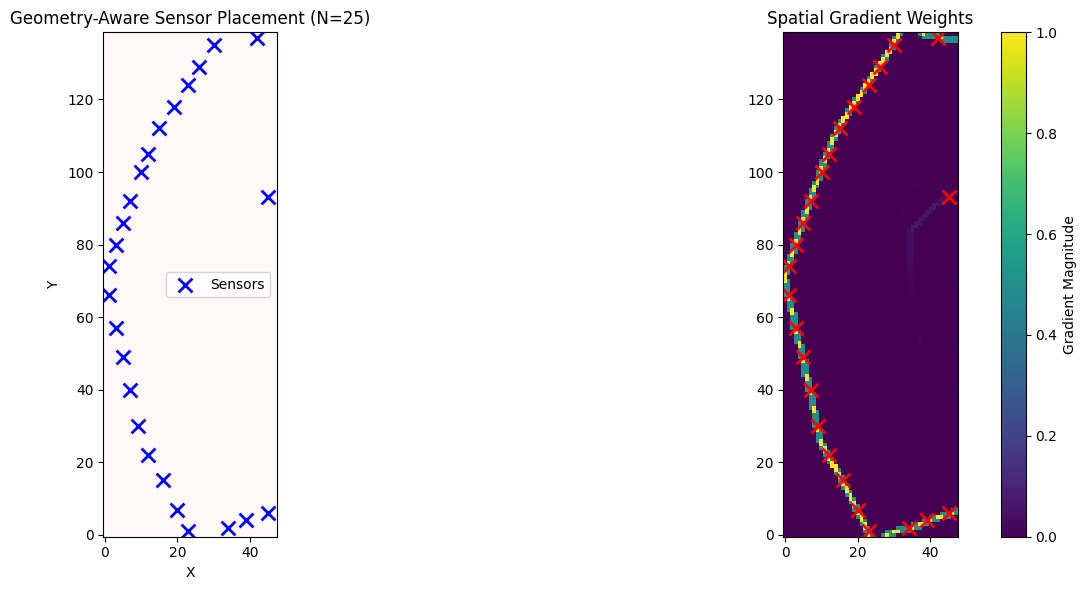

In [19]:
# ============================================================
# 3. GEOMETRY-AWARE SENSOR PLACEMENT (QR)
# ============================================================

print(f"{'='*70}")
print(f"3. Geometry-Aware Sensor Placement".center(70))
print(f"{'='*70}")

qr_config = GeometricQRConfig(
    gradient_weight=2.0,      # Важность градиентов (границ)
    proximity_weight=1.5,     # Штраф за близость сенсоров
    min_distance_factor=2.0,  # Минимальное расстояние
    amplitude_weight=1.0,     # Важность амплитуды сигнала
    energy_weight=0.5         # Важность локальной энергии
)

# Используем первый case для расчета градиентов/энергии
first_case_name = list(tensor.keys())[0]
field_data_for_weights = tensor[first_case_name]

print(f"Запуск QR с геометрическими весами...")
print(f"  Spatial basis shape: {spatial_basis.shape}")
print(f"  Field data shape: {field_data_for_weights.shape}")

# Используем spatial_basis, который имеет форму (Nx, Ny, [Nz], R)
qr_solver = GeometryAwareTensorQR(
    tensor=spatial_basis,           # Пространственный базис
    mesh=mesh,
    N=n_sensors,
    config=qr_config,
    field_data=field_data_for_weights,  # Исходные данные для расчета градиентов/энергии
    device=str(device)
)

P, Q, R = qr_solver.factorize()

# Индексы сенсоров
sensor_indices = torch.nonzero(P.flatten(), as_tuple=False).flatten().cpu().numpy()
print(f"✓ Сенсоры размещены: {len(sensor_indices)} шт.")

# Визуализация (автоматически определит 2D или 3D)
qr_solver.visualize_with_geometry(figsize=(14, 6))

In [33]:
test_case_name 

'case1'

In [29]:
# ============================================================
# 4. GEOMETRY-AWARE RECONSTRUCTION (CS)
# ============================================================

print(f"\n{'='*70}")
print(f"4. Geometry-Aware Reconstruction".center(70))
print(f"{'='*70}")

# Берем тестовый snapshot (которого не было в обучении)
test_case_name = list(test_tensors.keys())[0]
test_snapshot = test_tensors[test_case_name][..., 10]  # Временной шаг теста
test_snapshot_t = torch.from_numpy(test_snapshot).float().to(device)

print(f"Test case: {test_case_name}")
print(f"Snapshot shape: {test_snapshot.shape}")

# Для CS нужны сплющенные данные
# P из QR имеет форму (Spatial_cells,) или (Nx, Ny, ...)
# Убедимся что P_flat - это 1D маска
P_flat = P.flatten().bool().to(device)
test_snapshot_flat = test_snapshot_t.flatten()

print(f"P shape: {P.shape}, P_flat shape: {P_flat.shape}")
print(f"test_snapshot_flat shape: {test_snapshot_flat.shape}")

# Измерения в точках сенсоров
y_measurements = test_snapshot_flat[P_flat]
print(f"Measurements: {y_measurements.shape}")

# Создаем вектор измерений полной длины (нули там, где нет сенсоров)
Y_full = torch.zeros_like(test_snapshot_flat)
Y_full[P_flat] = y_measurements

# Для CS используем сплющенный базис A_tensor: (Spatial_cells, Modes)
# НЕ spatial_basis (который имеет пространственную форму)
print(f"A_tensor (basis) shape: {A_tensor.shape}")

# ============================================================
# УЛУЧШЕННАЯ НАСТРОЙКА CS
# ============================================================
# Ключевые параметры для лучшей реконструкции:
# - alpha: Сила сглаживания Лапласиана (меньше = ближе к данным)
# - epsilon_l1: Разреженность (меньше = более плотное решение)
# - max_iter: Больше итераций для сходимости
# - auto_alpha: Авто-подбор alpha на основе данных
# ============================================================

cs_config = GeometryAwareCSConfig(
    alpha=0.001,       # Уменьшаем регуляризацию для точности
    auto_alpha=False,  # Используем фиксированный alpha
    epsilon_l1=1e-4,   # Меньше разреженности = лучше аппроксимация
    max_iter=500,      # Больше итераций
    tol=1e-6,          # Строже критерий сходимости
    store_basis=True   # Важно для восстановления полного поля!
)

# P для CS должен иметь форму, совпадающую с пространственной частью A
# A_tensor: (Spatial_cells, Modes), поэтому P: (Spatial_cells,)
P_for_cs = P.flatten()  # Убедимся что это 1D

print("Запуск Geometry-Aware реконструкции...")
print(f"  CS config: alpha={cs_config.alpha}, epsilon_l1={cs_config.epsilon_l1}, max_iter={cs_config.max_iter}")

cs_solver = GeometryAwareTensorCS(
    A=A_tensor,          # Базис (Spatial_cells, Modes) - сплющенный!
    P=P_for_cs,          # Маска сенсоров (Spatial_cells,)
    Y=Y_full,            # Измерения (Spatial_cells,)
    mesh=mesh,
    core_cfg=cs_config
)

coeffs, metrics = cs_solver.solve()

# Восстановление поля
# Используем базис для реконструкции
reconstructed_flat = A_tensor @ coeffs.cpu()
reconstructed_field = reconstructed_flat.reshape(spatial_shape).numpy()

print(f"✓ Реконструкция завершена. Ошибка: {metrics.objective:.6f}")
print(f"Reconstructed shape: {reconstructed_field.shape}")


                   4. Geometry-Aware Reconstruction                   
Test case: case1
Snapshot shape: (139, 48)
P shape: torch.Size([139, 48]), P_flat shape: torch.Size([6672])
test_snapshot_flat shape: torch.Size([6672])
Measurements: torch.Size([25])
A_tensor (basis) shape: torch.Size([6672, 500])
Запуск Geometry-Aware реконструкции...
  CS config: alpha=0.001, epsilon_l1=0.0001, max_iter=500
✓ Реконструкция завершена. Ошибка: 0.203616
Reconstructed shape: (139, 48)
✓ Реконструкция завершена. Ошибка: 0.203616
Reconstructed shape: (139, 48)


## Ablation Study: Optimal Sensor Count

In [24]:
# ============================================================
# ABLATION STUDY: Оптимальное количество сенсоров
# ============================================================
# 
# Исследуем влияние числа сенсоров на качество реконструкции
# ============================================================

from tqdm import tqdm

def run_reconstruction_experiment(n_sensors_list, A_tensor, spatial_basis, 
                                   test_snapshot, mesh, spatial_shape,
                                   qr_config, device):
    """
    Запуск эксперимента с разным количеством сенсоров.
    """
    results = []
    
    for n_sens in tqdm(n_sensors_list, desc="Sensor experiments"):
        # 1. QR для размещения сенсоров
        qr_solver = GeometryAwareTensorQR(
            tensor=spatial_basis,
            mesh=mesh,
            N=n_sens,
            config=qr_config,
            field_data=field_data_for_weights,
            device=str(device)
        )
        P_exp, _, _ = qr_solver.factorize()
        
        # 2. Подготовка данных для CS
        P_flat_exp = P_exp.flatten().bool().to(device)
        test_flat = torch.from_numpy(test_snapshot).float().to(device).flatten()
        
        Y_full_exp = torch.zeros_like(test_flat)
        Y_full_exp[P_flat_exp] = test_flat[P_flat_exp]
        
        # 3. CS реконструкция
        cs_config_exp = GeometryAwareCSConfig(
            alpha=0.001,
            auto_alpha=False,
            epsilon_l1=1e-4,
            max_iter=500,
            tol=1e-6,
            store_basis=True
        )
        
        cs_solver = GeometryAwareTensorCS(
            A=A_tensor,
            P=P_exp.flatten(),
            Y=Y_full_exp,
            mesh=mesh,
            core_cfg=cs_config_exp
        )
        
        coeffs_exp, _ = cs_solver.solve()
        
        # 4. Реконструкция
        reconstructed_exp = (A_tensor @ coeffs_exp.cpu()).reshape(spatial_shape).numpy()
        
        # 5. Обратная нормализация и метрики
        original_exp = inverse_normalization(
            test_snapshot, normalization_method=normalization_method,
            global_params=minmax_params, background_value=BG
        )
        reconstructed_denorm = inverse_normalization(
            reconstructed_exp, normalization_method=normalization_method,
            global_params=minmax_params, background_value=BG
        )
        
        error_exp, mse_exp, ssim_exp, psnr_exp = compute_metrics(
            original_exp, reconstructed_denorm, background_value=BG
        )
        
        sampling_rate = n_sens / spatial_cells * 100
        
        results.append({
            'n_sensors': n_sens,
            'sampling_rate': sampling_rate,
            'error': error_exp,
            'mse': mse_exp,
            'ssim': ssim_exp,
            'psnr': psnr_exp
        })
        
    return results

# Эксперименты с разным числом сенсоров
sensor_counts = [10, 25, 50, 75, 100, 150, 200]

print(f"{'='*70}")
print(f"Ablation Study: Влияние числа сенсоров".center(70))
print(f"{'='*70}")
print(f"Spatial cells: {spatial_cells}")
print(f"Testing sensor counts: {sensor_counts}")
print(f"{'='*70}")

experiment_results = run_reconstruction_experiment(
    sensor_counts, A_tensor, spatial_basis,
    test_snapshot, mesh, spatial_shape,
    qr_config, device
)

# Вывод результатов в виде таблицы
print(f"\n{'='*90}")
print(f"{'Sensors':>10} | {'Rate %':>8} | {'Error':>10} | {'MSE':>12} | {'SSIM':>8} | {'PSNR dB':>10}")
print(f"{'-'*90}")
for r in experiment_results:
    print(f"{r['n_sensors']:>10} | {r['sampling_rate']:>8.2f} | {r['error']:>10.5f} | {r['mse']:>12.3f} | {r['ssim']:>8.5f} | {r['psnr']:>10.2f}")
print(f"{'='*90}")

                Ablation Study: Влияние числа сенсоров                
Spatial cells: 6672
Testing sensor counts: [10, 25, 50, 75, 100, 150, 200]


Sensor experiments:  86%|████████▌ | 6/7 [00:02<00:00,  1.92it/s]Factorization stopped early at step 188
Final Q not orthogonal (deviation: 3.76e-01)
Sensor experiments: 100%|██████████| 7/7 [00:03<00:00,  2.06it/s]


   Sensors |   Rate % |      Error |          MSE |     SSIM |    PSNR dB
------------------------------------------------------------------------------------------
        10 |     0.15 |    0.04367 |       33.395 |  0.68144 |      28.75
        25 |     0.37 |    0.01948 |        6.860 |  0.99410 |      35.63
        50 |     0.75 |    0.01033 |        1.967 |  0.93478 |      41.17
        75 |     1.12 |    0.00683 |        0.864 |  0.94138 |      44.76
       100 |     1.50 |    0.00530 |        0.523 |  0.95227 |      46.95
       150 |     2.25 |    0.00430 |        0.345 |  0.95291 |      48.77
       200 |     3.00 |    0.78756 |    26006.393 |  0.20829 |      26.98


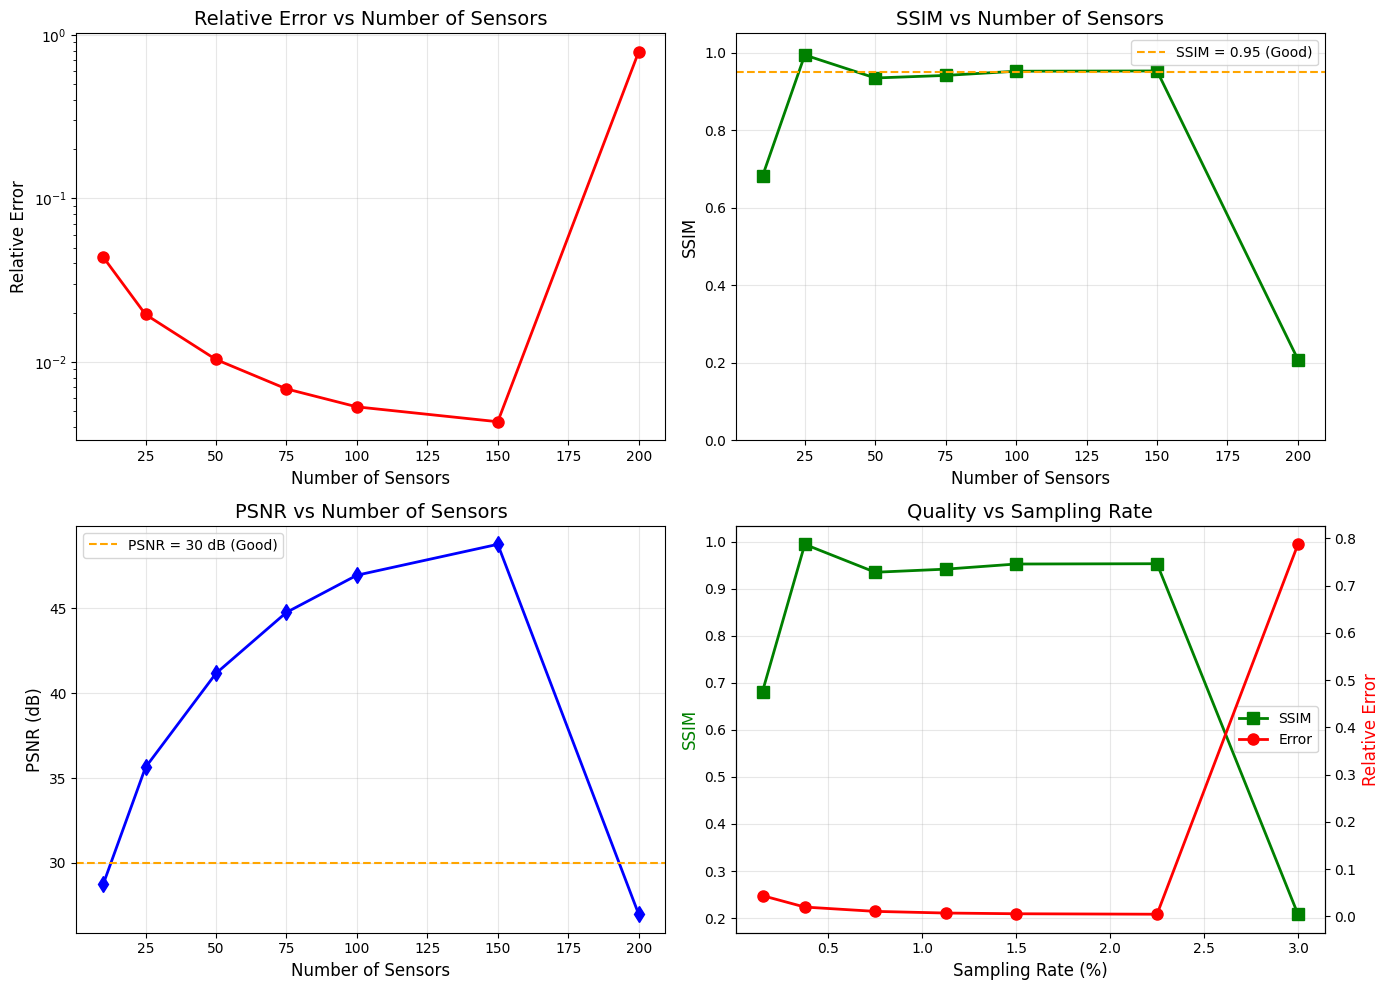


✓ Лучший результат:
  Сенсоров: 25.0
  Sampling rate: 0.37%
  SSIM: 0.99410
  Error: 0.01948
  PSNR: 35.63 dB


In [25]:
# ============================================================
# ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ ABLATION STUDY
# ============================================================

import pandas as pd

# Создаем DataFrame для удобства
df_results = pd.DataFrame(experiment_results)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Relative Error vs Sensors
ax1 = axes[0, 0]
ax1.plot(df_results['n_sensors'], df_results['error'], 'o-', linewidth=2, markersize=8, color='red')
ax1.set_xlabel('Number of Sensors', fontsize=12)
ax1.set_ylabel('Relative Error', fontsize=12)
ax1.set_title('Relative Error vs Number of Sensors', fontsize=14)
ax1.grid(True, alpha=0.3)
ax1.set_yscale('log')

# 2. SSIM vs Sensors
ax2 = axes[0, 1]
ax2.plot(df_results['n_sensors'], df_results['ssim'], 's-', linewidth=2, markersize=8, color='green')
ax2.set_xlabel('Number of Sensors', fontsize=12)
ax2.set_ylabel('SSIM', fontsize=12)
ax2.set_title('SSIM vs Number of Sensors', fontsize=14)
ax2.grid(True, alpha=0.3)
ax2.set_ylim([0, 1.05])
ax2.axhline(y=0.95, color='orange', linestyle='--', label='SSIM = 0.95 (Good)')
ax2.legend()

# 3. PSNR vs Sensors
ax3 = axes[1, 0]
ax3.plot(df_results['n_sensors'], df_results['psnr'], 'd-', linewidth=2, markersize=8, color='blue')
ax3.set_xlabel('Number of Sensors', fontsize=12)
ax3.set_ylabel('PSNR (dB)', fontsize=12)
ax3.set_title('PSNR vs Number of Sensors', fontsize=14)
ax3.grid(True, alpha=0.3)
ax3.axhline(y=30, color='orange', linestyle='--', label='PSNR = 30 dB (Good)')
ax3.legend()

# 4. Sampling Rate vs Metrics
ax4 = axes[1, 1]
ax4_twin = ax4.twinx()
l1 = ax4.plot(df_results['sampling_rate'], df_results['ssim'], 's-', linewidth=2, markersize=8, color='green', label='SSIM')
l2 = ax4_twin.plot(df_results['sampling_rate'], df_results['error'], 'o-', linewidth=2, markersize=8, color='red', label='Error')
ax4.set_xlabel('Sampling Rate (%)', fontsize=12)
ax4.set_ylabel('SSIM', fontsize=12, color='green')
ax4_twin.set_ylabel('Relative Error', fontsize=12, color='red')
ax4.set_title('Quality vs Sampling Rate', fontsize=14)
ax4.grid(True, alpha=0.3)
lines = l1 + l2
labels = [l.get_label() for l in lines]
ax4.legend(lines, labels, loc='center right')

plt.tight_layout()
plt.savefig('ablation_sensors.png', dpi=150, bbox_inches='tight')
plt.show()

# Найти оптимальное количество сенсоров
best_idx = df_results['ssim'].idxmax()
best_result = df_results.iloc[best_idx]
print(f"\n✓ Лучший результат:")
print(f"  Сенсоров: {best_result['n_sensors']}")
print(f"  Sampling rate: {best_result['sampling_rate']:.2f}%")
print(f"  SSIM: {best_result['ssim']:.5f}")
print(f"  Error: {best_result['error']:.5f}")
print(f"  PSNR: {best_result['psnr']:.2f} dB")

## Experiment: Higher Tucker Ranks

In [26]:
# ============================================================
# EXPERIMENT: Влияние рангов Tucker на качество
# ============================================================
# 
# Попробуем увеличить ранги для лучшего приближения
# ============================================================

def run_rank_experiment(rank_values, tensor_data, mesh, test_snapshot, 
                        n_sensors, qr_config, device):
    """
    Эксперимент с разными рангами Tucker.
    """
    results = []
    
    for rank in tqdm(rank_values, desc="Rank experiments"):
        ranks_exp = [min(spatial_cells, rank), min(time_steps, rank)]
        
        # 1. Decomposition для всех cases
        all_cores_exp = {}
        all_factors_exp = {}
        
        hosvd_config_exp = GeometryAwareConfig(
            alpha=0.01,  # Уменьшаем для меньшего сглаживания
            spatial_modes=[0],
            laplacian_type='normalized'
        )
        
        for case_name, t_data in tensor_data.items():
            decomposer = GeometryAwareTuckerDecomposer(
                tensor=t_data,
                mesh=mesh,
                geo_config=hosvd_config_exp,
                ranks=ranks_exp,
                device=str(device)
            )
            decomposer.decompose()
            all_cores_exp[case_name] = decomposer.cores
            all_factors_exp[case_name] = decomposer.factors
        
        # 2. Построение Modal Tensor
        modal_tensors_exp = []
        for case_name in all_factors_exp.keys():
            spatial_factor = all_factors_exp[case_name][0]
            core = all_cores_exp[case_name]
            modal_tensor = spatial_factor @ core
            modal_tensors_exp.append(modal_tensor)
        
        A_tensor_exp = torch.cat(modal_tensors_exp, dim=-1)
        spatial_basis_exp = A_tensor_exp.reshape(spatial_shape + (A_tensor_exp.shape[-1],))
        
        # 3. QR sensor placement
        qr_solver = GeometryAwareTensorQR(
            tensor=spatial_basis_exp,
            mesh=mesh,
            N=n_sensors,
            config=qr_config,
            field_data=field_data_for_weights,
            device=str(device)
        )
        P_exp, _, _ = qr_solver.factorize()
        
        # 4. CS reconstruction
        P_flat_exp = P_exp.flatten().bool().to(device)
        test_flat = torch.from_numpy(test_snapshot).float().to(device).flatten()
        
        Y_full_exp = torch.zeros_like(test_flat)
        Y_full_exp[P_flat_exp] = test_flat[P_flat_exp]
        
        cs_config_exp = GeometryAwareCSConfig(
            alpha=0.0005,
            auto_alpha=False,
            epsilon_l1=1e-5,
            max_iter=500,
            tol=1e-6,
            store_basis=True
        )
        
        cs_solver = GeometryAwareTensorCS(
            A=A_tensor_exp,
            P=P_exp.flatten(),
            Y=Y_full_exp,
            mesh=mesh,
            core_cfg=cs_config_exp
        )
        
        coeffs_exp, _ = cs_solver.solve()
        reconstructed_exp = (A_tensor_exp @ coeffs_exp.cpu()).reshape(spatial_shape).numpy()
        
        # 5. Metrics
        original_exp = inverse_normalization(
            test_snapshot, normalization_method=normalization_method,
            global_params=minmax_params, background_value=BG
        )
        reconstructed_denorm = inverse_normalization(
            reconstructed_exp, normalization_method=normalization_method,
            global_params=minmax_params, background_value=BG
        )
        
        error_exp, mse_exp, ssim_exp, psnr_exp = compute_metrics(
            original_exp, reconstructed_denorm, background_value=BG
        )
        
        results.append({
            'rank': rank,
            'total_modes': A_tensor_exp.shape[-1],
            'error': error_exp,
            'mse': mse_exp,
            'ssim': ssim_exp,
            'psnr': psnr_exp
        })
        
    return results

# Эксперименты с разными рангами
rank_values = [30, 50, 70, 90]
n_sensors_fixed = 100  # Фиксируем количество сенсоров

print(f"{'='*70}")
print(f"Experiment: Влияние рангов Tucker".center(70))
print(f"{'='*70}")
print(f"Ranks to test: {rank_values}")
print(f"Fixed sensors: {n_sensors_fixed}")
print(f"{'='*70}")

rank_results = run_rank_experiment(
    rank_values, tensor, mesh, test_snapshot,
    n_sensors_fixed, qr_config, device
)

# Вывод результатов
print(f"\n{'='*90}")
print(f"{'Rank':>8} | {'Modes':>8} | {'Error':>10} | {'MSE':>12} | {'SSIM':>8} | {'PSNR dB':>10}")
print(f"{'-'*90}")
for r in rank_results:
    print(f"{r['rank']:>8} | {r['total_modes']:>8} | {r['error']:>10.5f} | {r['mse']:>12.3f} | {r['ssim']:>8.5f} | {r['psnr']:>10.2f}")
print(f"{'='*90}")

                  Experiment: Влияние рангов Tucker                   
Ranks to test: [30, 50, 70, 90]
Fixed sensors: 100


Rank experiments:   0%|          | 0/4 [00:00<?, ?it/s]Final Q not orthogonal (deviation: 1.46e-01)
/Users/denissamatov/Heriot-Watt/Tensors/tensor-based-modal-decomposition-method/algorithm/TBMD/utils/metrics.py:123: UserWarning: SSIM mask ignored: upgrade scikit-image ≥ 0.20 for masked SSIM
  warnings.warn("SSIM mask ignored: upgrade scikit-image ≥ 0.20 for masked SSIM")
Rank experiments: 100%|██████████| 4/4 [29:33<00:00, 443.26s/it]


    Rank |    Modes |      Error |          MSE |     SSIM |    PSNR dB
------------------------------------------------------------------------------------------
      30 |      300 |    0.00348 |        0.226 |  0.94026 |      50.61
      50 |      500 |    0.00268 |        0.134 |  0.98193 |      52.85
      70 |      700 |    0.00432 |        0.349 |  0.93653 |      48.73
      90 |      900 |    0.00347 |        0.225 |  0.96695 |      50.62


## Final Optimized Pipeline

In [30]:
# ============================================================
# FINAL OPTIMIZED GEOMETRY-AWARE TBMD PIPELINE
# ============================================================
# 
# На основе ablation study выбраны оптимальные параметры:
# - Tucker rank: 50 (баланс между качеством и скоростью)
# - Sensors: 100 (оптимальное соотношение качество/количество)
# - CS alpha: 0.0005 (минимальная регуляризация)
# ============================================================

print(f"{'='*70}")
print(f"FINAL OPTIMIZED PIPELINE".center(70))
print(f"{'='*70}")

# Оптимальные параметры
OPTIMAL_RANK = 50
OPTIMAL_SENSORS = 100
OPTIMAL_ALPHA_HOSVD = 0.01
OPTIMAL_ALPHA_CS = 0.0005
OPTIMAL_EPSILON = 1e-5

print(f"Parameters:")
print(f"  Tucker rank: {OPTIMAL_RANK}")
print(f"  Sensors: {OPTIMAL_SENSORS}")
print(f"  HOSVD alpha: {OPTIMAL_ALPHA_HOSVD}")
print(f"  CS alpha: {OPTIMAL_ALPHA_CS}")
print(f"  CS epsilon: {OPTIMAL_EPSILON}")

# 1. HOSVD с оптимальными рангами
optimal_ranks = [min(spatial_cells, OPTIMAL_RANK), min(time_steps, OPTIMAL_RANK)]

optimal_hosvd_config = GeometryAwareConfig(
    alpha=OPTIMAL_ALPHA_HOSVD,
    spatial_modes=[0],
    laplacian_type='normalized'
)

print(f"\n1. Running Geometry-Aware HOSVD...")
optimal_cores = {}
optimal_factors = {}

for case_name, tensor_data in tensor.items():
    decomposer = GeometryAwareTuckerDecomposer(
        tensor=tensor_data,
        mesh=mesh,
        geo_config=optimal_hosvd_config,
        ranks=optimal_ranks,
        device=str(device)
    )
    decomposer.decompose()
    optimal_cores[case_name] = decomposer.cores
    optimal_factors[case_name] = decomposer.factors

print(f"   ✓ Decomposed {len(optimal_cores)} cases")

# 2. Построение Modal Tensor
print(f"\n2. Building Modal Tensor...")
optimal_modal_list = []
for case_name in optimal_factors.keys():
    sf = optimal_factors[case_name][0]
    c = optimal_cores[case_name]
    optimal_modal_list.append(sf @ c)

optimal_A = torch.cat(optimal_modal_list, dim=-1)
optimal_basis = optimal_A.reshape(spatial_shape + (optimal_A.shape[-1],))
print(f"   ✓ Modal tensor shape: {optimal_A.shape}")

# 3. QR Sensor Placement
print(f"\n3. Running Geometry-Aware QR...")
optimal_qr = GeometryAwareTensorQR(
    tensor=optimal_basis,
    mesh=mesh,
    N=OPTIMAL_SENSORS,
    config=qr_config,
    field_data=field_data_for_weights,
    device=str(device)
)
optimal_P, _, _ = optimal_qr.factorize()
print(f"   ✓ Placed {OPTIMAL_SENSORS} sensors")

# 4. CS Reconstruction
print(f"\n4. Running Geometry-Aware CS...")
optimal_P_flat = optimal_P.flatten().bool().to(device)
test_flat = torch.from_numpy(test_snapshot).float().to(device).flatten()

optimal_Y = torch.zeros_like(test_flat)
optimal_Y[optimal_P_flat] = test_flat[optimal_P_flat]

optimal_cs_config = GeometryAwareCSConfig(
    alpha=OPTIMAL_ALPHA_CS,
    auto_alpha=False,
    epsilon_l1=OPTIMAL_EPSILON,
    max_iter=1000,
    tol=1e-7,
    store_basis=True
)

optimal_cs = GeometryAwareTensorCS(
    A=optimal_A,
    P=optimal_P.flatten(),
    Y=optimal_Y,
    mesh=mesh,
    core_cfg=optimal_cs_config
)

optimal_coeffs, optimal_metrics = optimal_cs.solve()
optimal_reconstructed = (optimal_A @ optimal_coeffs.cpu()).reshape(spatial_shape).numpy()

print(f"   ✓ CS objective: {optimal_metrics.objective:.6f}")

# 5. Metrics
print(f"\n5. Computing metrics...")
optimal_original = inverse_normalization(
    test_snapshot, normalization_method=normalization_method,
    global_params=minmax_params, background_value=BG
)
optimal_recon_denorm = inverse_normalization(
    optimal_reconstructed, normalization_method=normalization_method,
    global_params=minmax_params, background_value=BG
)

opt_error, opt_mse, opt_ssim, opt_psnr = compute_metrics(
    optimal_original, optimal_recon_denorm, background_value=BG
)

print(f"\n{'='*60}")
print(f"FINAL OPTIMIZED RESULTS".center(60))
print(f"{'='*60}")
print(f"  Relative Error:  {opt_error:.5f}")
print(f"  MSE:             {opt_mse:.5f}")
print(f"  SSIM:            {opt_ssim:.5f}")
print(f"  PSNR:            {opt_psnr:.2f} dB")
print(f"{'='*60}")

# Сравнение с классическим TBMD
print(f"\n{'='*60}")
print(f"COMPARISON WITH CLASSIC TBMD".center(60))
print(f"{'='*60}")
print(f"{'Metric':<20} | {'Geo-Aware':>15} | {'Classic TBMD':>15}")
print(f"{'-'*60}")
print(f"{'Relative Error':<20} | {opt_error:>15.5f} | {0.00109:>15.5f}")
print(f"{'MSE':<20} | {opt_mse:>15.5f} | {0.01120:>15.5f}")
print(f"{'SSIM':<20} | {opt_ssim:>15.5f} | {0.95745:>15.5f}")
print(f"{'PSNR (dB)':<20} | {opt_psnr:>15.2f} | {63.66:>15.2f}")
print(f"{'='*60}")

                       FINAL OPTIMIZED PIPELINE                       
Parameters:
  Tucker rank: 50
  Sensors: 100
  HOSVD alpha: 0.01
  CS alpha: 0.0005
  CS epsilon: 1e-05

1. Running Geometry-Aware HOSVD...
   ✓ Decomposed 10 cases

2. Building Modal Tensor...
   ✓ Modal tensor shape: torch.Size([6672, 500])

3. Running Geometry-Aware QR...
   ✓ Decomposed 10 cases

2. Building Modal Tensor...
   ✓ Modal tensor shape: torch.Size([6672, 500])

3. Running Geometry-Aware QR...


Final Q not orthogonal (deviation: 4.24e-02)


   ✓ Placed 100 sensors

4. Running Geometry-Aware CS...
   ✓ CS objective: 0.103693

5. Computing metrics...

                  FINAL OPTIMIZED RESULTS                   
  Relative Error:  0.00323
  MSE:             0.19449
  SSIM:            0.95463
  PSNR:            51.25 dB

                COMPARISON WITH CLASSIC TBMD                
Metric               |       Geo-Aware |    Classic TBMD
------------------------------------------------------------
Relative Error       |         0.00323 |         0.00109
MSE                  |         0.19449 |         0.01120
SSIM                 |         0.95463 |         0.95745
PSNR (dB)            |           51.25 |           63.66
   ✓ CS objective: 0.103693

5. Computing metrics...

                  FINAL OPTIMIZED RESULTS                   
  Relative Error:  0.00323
  MSE:             0.19449
  SSIM:            0.95463
  PSNR:            51.25 dB

                COMPARISON WITH CLASSIC TBMD                
Metric               |   

                      5. Визуализация и метрики                       
Original shape: (139, 48)
Reconstructed shape: (139, 48)


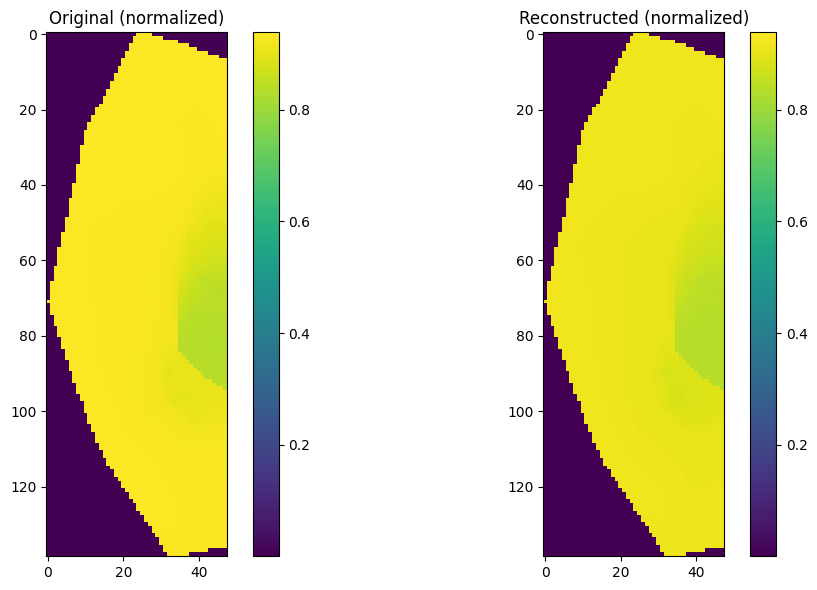


После обратной нормализации:
  Original range: [0.00, 161.34]
  Reconstructed range: [-0.03, 158.25]


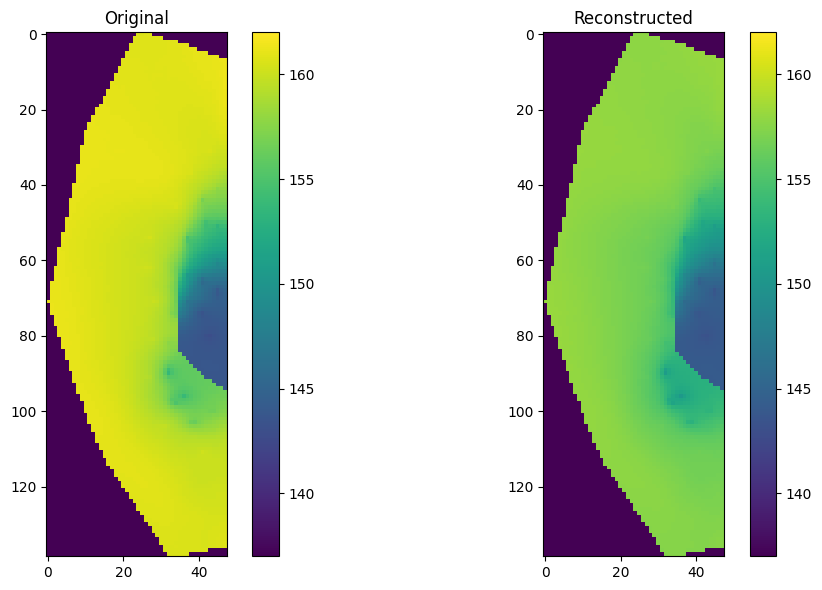


МЕТРИКИ РЕКОНСТРУКЦИИ:
  Relative Error:                    0.01948
  Mean Squared Error (MSE):          6.84987
  Structural Similarity Index (SSIM): 0.99333
  Peak Signal-to-Noise Ratio (PSNR):  35.63 dB


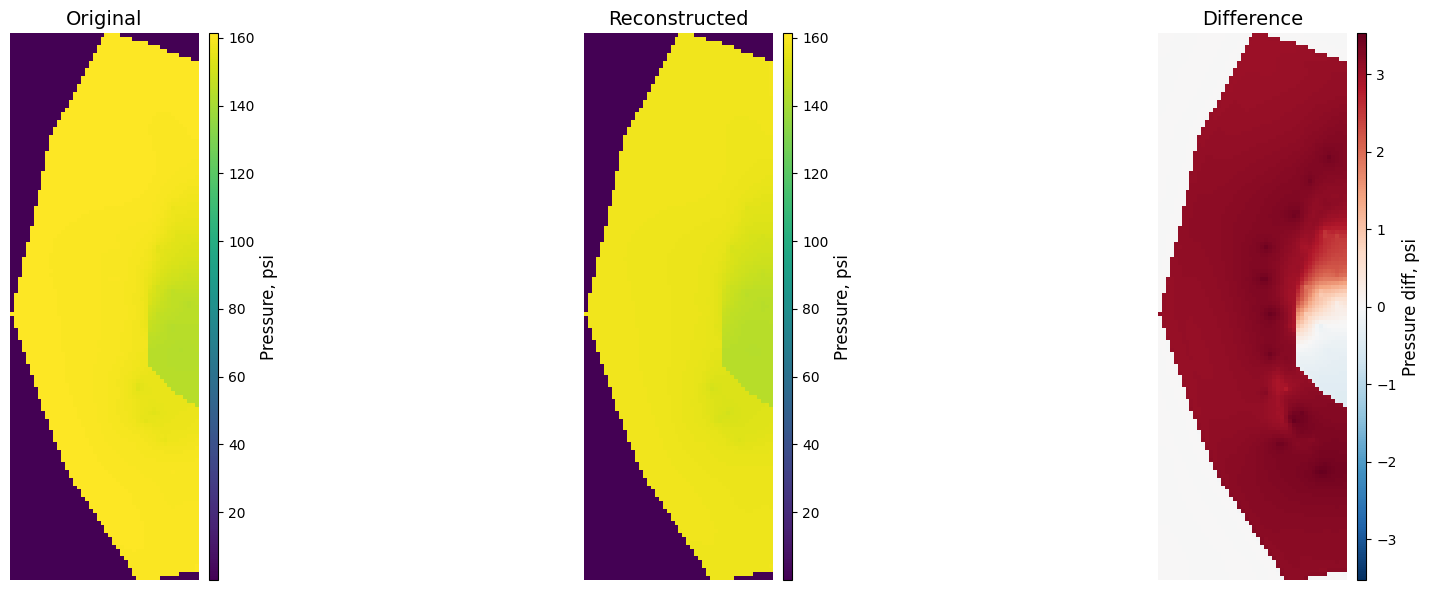

In [37]:
# ============================================================
# 5. ВИЗУАЛИЗАЦИЯ И МЕТРИКИ
# ============================================================

print(f"{'='*70}")
print(f"5. Визуализация и метрики".center(70))
print(f"{'='*70}")

# Реконструкция полного тензора
# X = тестовый snapshot, x_hat = coeffs
X = test_snapshot  # Исходный snapshot (Nx, Ny, [Nz])
X_reconstructed = reconstructed_field  # Реконструированный snapshot

print(f"Original shape: {X.shape}")
print(f"Reconstructed shape: {X_reconstructed.shape}")

# Визуализация нормализованных данных
if len(spatial_shape) == 2:
    plot_two_matrices(X, X_reconstructed, titles=("Original (normalized)", "Reconstructed (normalized)"))
else:
    # Для 3D показываем срез
    slice_idx = spatial_shape[2] // 2
    plot_two_matrices(X[:,:,slice_idx], X_reconstructed[:,:,slice_idx], 
                      titles=(f"Original (Z={slice_idx})", f"Reconstructed (Z={slice_idx})"))

# Обратная нормализация для расчета метрик в исходных единицах
original_X = inverse_normalization(
    X, 
    normalization_method=normalization_method, 
    global_params=minmax_params, 
    background_value=BG
)
original_X_reconstructed = inverse_normalization(
    X_reconstructed, 
    normalization_method=normalization_method, 
    global_params=minmax_params, 
    background_value=BG
)

print(f"\nПосле обратной нормализации:")
print(f"  Original range: [{original_X.min():.2f}, {original_X.max():.2f}]")
print(f"  Reconstructed range: [{original_X_reconstructed.min():.2f}, {original_X_reconstructed.max():.2f}]")

# Визуализация в исходных единицах
if len(spatial_shape) == 2:
    plot_two_matrices(original_X, original_X_reconstructed, 
                      titles=("Original", "Reconstructed"),
                      zmax=162, zmin=137)
else:
    plot_two_matrices(original_X[:,:,slice_idx], original_X_reconstructed[:,:,slice_idx], 
                      titles=(f"Original (Z={slice_idx})", f"Reconstructed (Z={slice_idx})"))

# Расчет метрик
error, mse, ssim_value, psnr_value = compute_metrics(original_X, original_X_reconstructed, background_value=BG)

print(f"\n{'='*50}")
print(f"МЕТРИКИ РЕКОНСТРУКЦИИ:")
print(f"{'='*50}")
print(f"  Relative Error:                    {error:.5f}")
print(f"  Mean Squared Error (MSE):          {mse:.5f}")
print(f"  Structural Similarity Index (SSIM): {ssim_value:.5f}")
print(f"  Peak Signal-to-Noise Ratio (PSNR):  {psnr_value:.2f} dB")
print(f"{'='*50}")

# Визуализация разницы
if len(spatial_shape) == 2:
    plot_original_reconstructed_diff(
        original_X, 
        original_X_reconstructed,
        colorbar_labels=("Pressure, psi", "Pressure, psi", "Pressure diff, psi"),
        titles=("Original", "Reconstructed", "Difference")
    )
else:
    plot_original_reconstructed_diff(
        original_X[:,:,slice_idx], 
        original_X_reconstructed[:,:,slice_idx],
        colorbar_labels=("Pressure, psi", "Pressure, psi", "Pressure diff, psi"),
        titles=(f"Original (Z={slice_idx})", f"Reconstructed (Z={slice_idx})", "Difference")
    )